In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def binary_cross_entropy(y_true, y_pred):
    # clip to avoid log(0)
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + 
                    (1 - y_true) * np.log(1 - y_pred))

# test the loss function
print(binary_cross_entropy(1, 0.99))  # should be very low
print(binary_cross_entropy(1, 0.01))  # should be very high
print(binary_cross_entropy(1, 0.5))   # should be medium

0.01005033585350145
4.605170185988091
0.6931471805599453


In [2]:
class NeuralNetwork:
    def __init__(self):
        np.random.seed(42)
        self.W1 = np.random.randn(3, 4) * 0.01
        self.b1 = np.zeros(4)
        self.W2 = np.random.randn(4, 2) * 0.01
        self.b2 = np.zeros(2)
    
    def forward(self, X):
        self.X  = X
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2
    
    def backward(self, X, y, lr=0.01):
        m = X.shape[0]  # number of samples
        
        # output layer gradient
        # dL/dz2 = a2 - y  (sigmoid + cross entropy combined)
        dz2 = self.a2 - y              # shape (m, 2)
        dW2 = np.dot(self.a1.T, dz2) / m  # shape (4, 2)
        db2 = np.sum(dz2, axis=0) / m     # shape (2,)
        
        # hidden layer gradient
        # chain rule: flow gradient back through W2
        da1 = np.dot(dz2, self.W2.T)      # shape (m, 4)
        
        # ReLU derivative: 1 where z1 > 0, else 0
        dz1 = da1 * (self.z1 > 0)         # shape (m, 4)
        dW1 = np.dot(X.T, dz1) / m        # shape (3, 4)
        db1 = np.sum(dz1, axis=0) / m     # shape (4,)
        
        # update weights
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

Epoch    0 → Loss: 0.6931
Epoch  100 → Loss: 0.6930
Epoch  200 → Loss: 0.6918
Epoch  300 → Loss: 0.6796
Epoch  400 → Loss: 0.5905
Epoch  500 → Loss: 0.4414
Epoch  600 → Loss: 0.3841
Epoch  700 → Loss: 0.3624
Epoch  800 → Loss: 0.3121
Epoch  900 → Loss: 0.1318


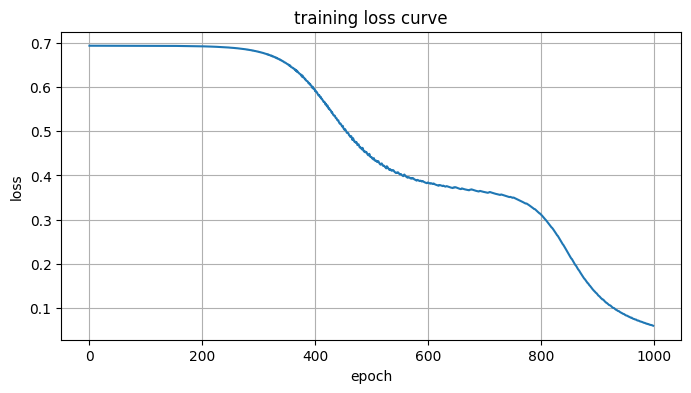


Final predictions:
[[0.08991623 0.9097583 ]
 [0.92763258 0.07205971]
 [0.96495394 0.0348394 ]
 [0.03424077 0.96577246]]

Actual:
[[0 1]
 [1 0]
 [1 0]
 [0 1]]


In [4]:
import matplotlib.pyplot as plt
class NeuralNetwork:
    def __init__(self):
        np.random.seed(42)
        self.W1 = np.random.randn(3, 4) * 0.01
        self.b1 = np.zeros(4)
        self.W2 = np.random.randn(4, 2) * 0.01
        self.b2 = np.zeros(2)
    
    def forward(self, X):
        self.X  = X
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2
    
    def backward(self, X, y, lr=0.01):
        m = X.shape[0]
        
        dz2 = self.a2 - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0) / m
        
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * (self.z1 > 0)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0) / m
        
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

# training loop
nn = NeuralNetwork()

# simple dataset — XOR problem
X = np.array([[0, 0, 1],
              [0, 1, 1],
              [1, 0, 1],
              [1, 1, 1]])

y = np.array([[0, 1],
              [1, 0],
              [1, 0],
              [0, 1]])

# train for 1000 epochs
losses = []
for epoch in range(1000):
    output = nn.forward(X)
    loss   = binary_cross_entropy(y, output)
    losses.append(loss)
    nn.backward(X, y, lr=0.1)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} → Loss: {loss:.4f}")

# plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training loss curve')
plt.grid(True)
plt.show()

# final predictions
print("\nFinal predictions:")
print(nn.forward(X))
print("\nActual:")
print(y)